In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from plotnine import *
from tslearn.clustering import TimeSeriesKMeans
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel as C
import tqdm
import pickle

/Users/smoon1/anaconda3/envs/ts/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
flood = pd.read_pickle('flood_df')

In [3]:
flood.iloc[0]

deployment_id                                        daily_happy_satyr
label                                                            flood
signal               {'time': [0, 567, 1009, 1639, 1765, 2080, 2395...
signal_padded        {'time': [0, 60, 120, 180, 240, 300, 867, 1309...
signal_sim           {'time': [0, 567, 1009, 1639, 1765, 2080, 2395...
signal_sim_padded    {'time': [0, 60, 120, 180, 240, 300, 867, 1309...
Name: 2461972, dtype: object

In [4]:
print(flood.shape)

(841, 6)


In [5]:
def z_score_outlier_remove(signal):
    time = signal['time']
    depth = signal['depth']
    
    z_score = (depth - np.mean(depth))/np.std(depth)
    ind_to_keep = np.argwhere(z_score < 2).flatten()
    time_tidy = time[ind_to_keep]
    depth_tidy = depth[ind_to_keep]
    
    return {"time": time_tidy, "depth": depth_tidy}

#function to remove negative points
def drop_negative_depths(signal):
    time = signal["time"]
    depth = signal["depth"]
    
    ind_to_keep = np.argwhere(depth >= 0).flatten()
    
    time_tidy = time[ind_to_keep]
    depth_tidy = depth[ind_to_keep] 
    
    return {"time": time_tidy, "depth": depth_tidy}

#function to remove gradient violations
def gradient_filter(signal):
    time = signal["time"]
    depth = signal["depth"]
    
    grad = np.diff(depth,prepend=depth[0])
    ind_to_keep = np.argwhere(np.abs(grad) < 279.4).flatten()
    
    time_tidy = time[ind_to_keep]
    depth_tidy = depth[ind_to_keep] 
    
    return {"time": time_tidy, "depth": depth_tidy}

def normalize(signal):
    time = signal["time"]
    depth = signal["depth"]
    
    depth_max = depth.max()
    depth_norm = depth/depth_max 
    time_max = time.max()
    time_norm = time/time_max 
    
    return({"time":time_norm,"depth":depth_norm})


flood_outlier_rm = flood.copy(deep = True)
flood_outlier_rm["signal"] = flood_outlier_rm.signal.apply(lambda x: gradient_filter(drop_negative_depths(z_score_outlier_remove(x))))

flood_pp = flood_outlier_rm.copy(deep=True)
flood_pp["signal"] = flood_outlier_rm.signal.apply(lambda x: normalize(x))

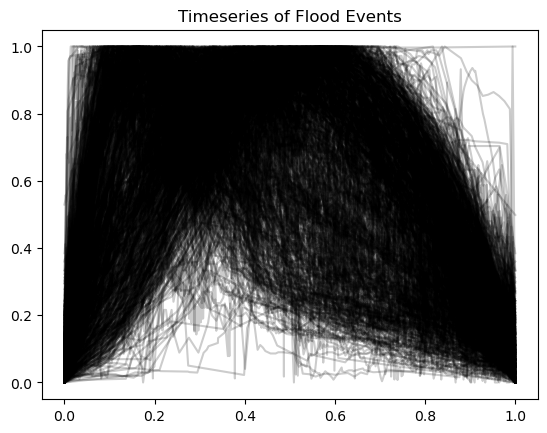

In [8]:
for xx in flood_pp["signal"]:
    plt.plot(xx['time'].ravel(), xx['depth'].ravel(),"k-",alpha=0.2)
    plt.title("Timeseries of Flood Events")

/var/folders/9j/ydcbw0c13g17vnbrxtyb0xkm0000gn/T/ipykernel_14706/3996451001.py:33: UserWarning: The figure layout has changed to tight


count of events per cluster:
 [[  0 110]
 [  1  29]
 [  2  73]
 [  3 268]
 [  4   5]
 [  5  50]
 [  6  45]
 [  7 251]
 [  8  10]]


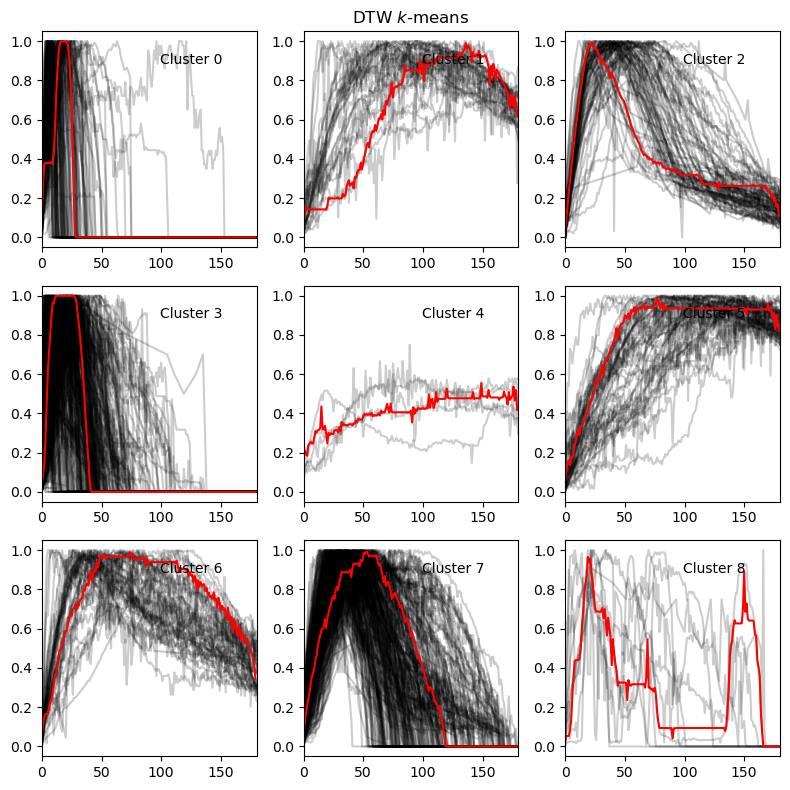

In [6]:
#transform timeseries signals from dictionary to matrix
T = flood_pp.apply(lambda x: len(x["signal"]["time"]), axis = 1).max()
N = len(flood_pp)
X = np.zeros((N, T, 1))

for i in range(N):
    x = flood_pp.iloc[i]
    signal = x["signal"]
    time = signal["time"]
    depth = signal["depth"]
    X[i, 0:len(depth)] = depth.reshape(-1,1)

#fit timeseries clustering
clusters = 9
samples = 841 
points = 180
model = TimeSeriesKMeans(n_clusters=clusters, metric="dtw", max_iter_barycenter=30, random_state=29)
y_pred = model.fit_predict(X[:samples,:points])

#plot clustered timseries
plt.figure(figsize=(8,8))
for yi in range(clusters):
    plt.subplot(3, 3, yi + 1)
    for xx in X[:samples][y_pred == yi]:
        plt.plot(xx.ravel(), "k-", alpha=.2)
    plt.plot(model.cluster_centers_[yi].ravel(), "r-")
    plt.xlim(0, points)
    #plt.ylim(-4, 4)
    plt.text(0.55, 0.85,'Cluster %d' % (yi),
             transform=plt.gca().transAxes)
    if yi == 1:
        plt.title("DTW $k$-means")
    plt.tight_layout()

print("count of events per cluster:\n",np.array(np.unique(y_pred,return_counts=True)).T)


In [7]:
flood_type1 = np.mean(model.cluster_centers_[[0,3]], axis=0).ravel()
flood_type2 = np.mean(model.cluster_centers_[[1,5,6]], axis=0).ravel()
flood_type3 = np.mean(model.cluster_centers_[[2,7]], axis=0).ravel()
flood_type4 = model.cluster_centers_[4].ravel()
flood_type5 = model.cluster_centers_[8].ravel()

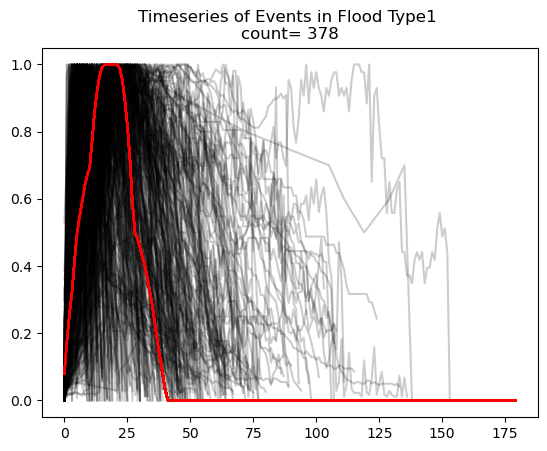

In [8]:
for xx in flood_pp.iloc[:samples][np.isin(y_pred, [0, 3])]["signal"]:
    plt.plot(xx['depth'].ravel(),"k-",alpha=0.2)
    plt.plot(flood_type1, "r-")
    plt.title("Timeseries of Events in Flood Type1 \ncount= %s"%((np.isin(y_pred, [0, 3])).sum()))

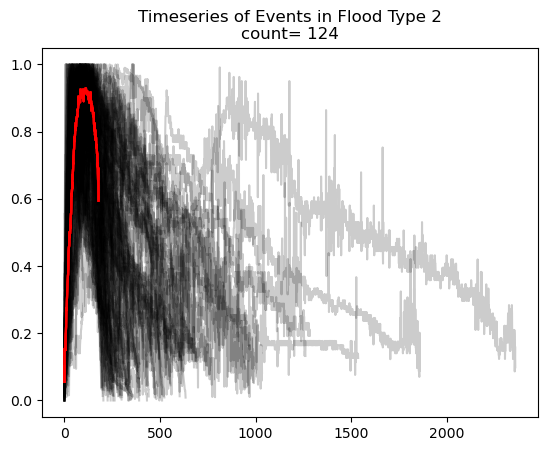

In [9]:
for xx in flood_pp.iloc[:samples][np.isin(y_pred, [1, 5, 6])]["signal"]:
    plt.plot(xx['depth'].ravel(),"k-",alpha=0.2)
    plt.plot(flood_type2, "r-")
    plt.title("Timeseries of Events in Flood Type 2\ncount= %s"%((np.isin(y_pred, [1, 5, 6])).sum()))

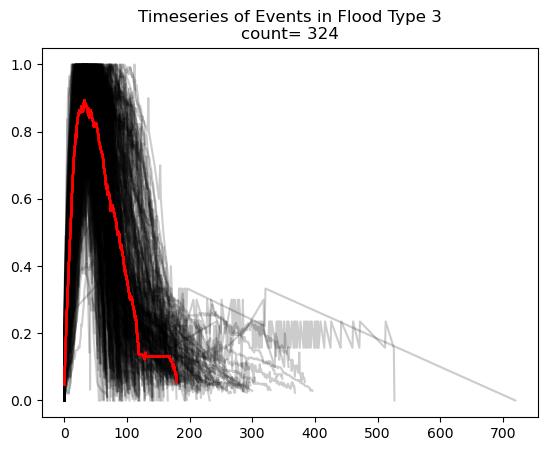

In [10]:
for xx in flood_pp.iloc[:samples][np.isin(y_pred, [2, 7])]["signal"]:
    plt.plot(xx['depth'].ravel(),"k-",alpha=0.2)
    plt.plot(flood_type3, "r-")
    plt.title("Timeseries of Events in Flood Type 3\ncount= %s"%((np.isin(y_pred, [2, 7])).sum()))

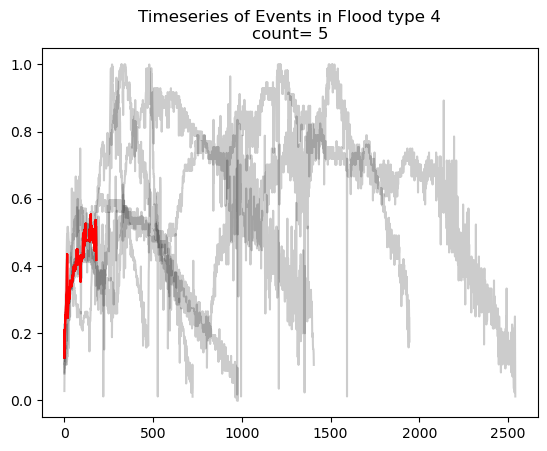

In [11]:
for xx in flood_pp.iloc[:samples][y_pred == 4]["signal"]:
    plt.plot(xx['depth'].ravel(),"k-",alpha=0.2)
    plt.plot(flood_type4, "r-")
    plt.title("Timeseries of Events in Flood type 4\ncount= %s"%((y_pred == 4).sum()))

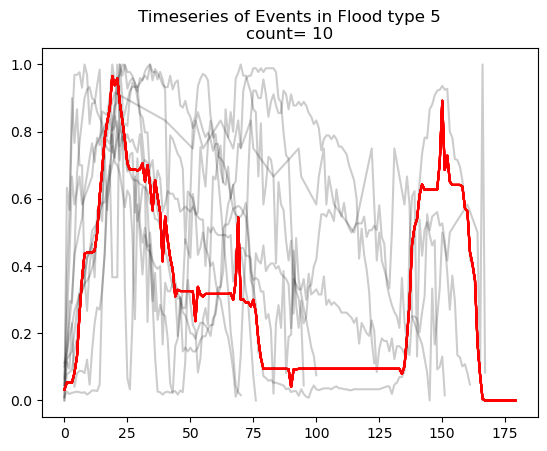

In [12]:
for xx in flood_pp.iloc[:samples][y_pred == 8]["signal"]:
    plt.plot(xx['depth'].ravel(),"k-",alpha=0.2)
    plt.plot(flood_type5, "r-")
    plt.title("Timeseries of Events in Flood type 5\ncount= %s"%((y_pred == 8).sum()))

## fit GP on flood type 1

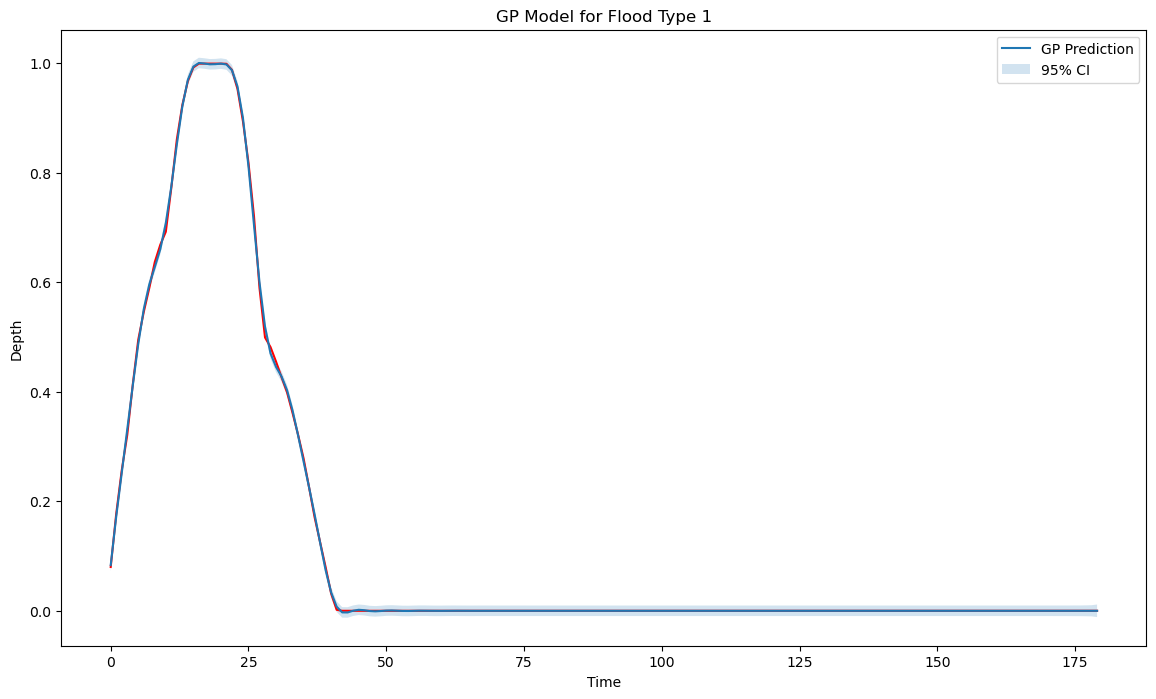

In [13]:
# Prepare features (X) and target (y)
X = np.arange(len(flood_type1)).reshape(-1, 1)
y = flood_type1

# Define the kernel and GP regressor
kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GP model
gp.fit(X, y)
 
y_pred, sigma = gp.predict(X, return_std=True)

# Visualization
plt.figure(figsize=(14, 8))
plt.plot(flood_type1, "r-")
plt.plot(X, y_pred, label=f'GP Prediction')
plt.fill_between(
    X.reshape(-1),
    y_pred - 1.96 * sigma,
    y_pred + 1.96 * sigma,
    alpha=0.2, label=f'95% CI'
    )

plt.xlabel('Time')
plt.ylabel('Depth')
plt.title('GP Model for Flood Type 1')
plt.legend()
plt.show()

In [14]:
with open('gp1.pkl','wb') as f:
    pickle.dump(gp,f)

## GP for flood type 2

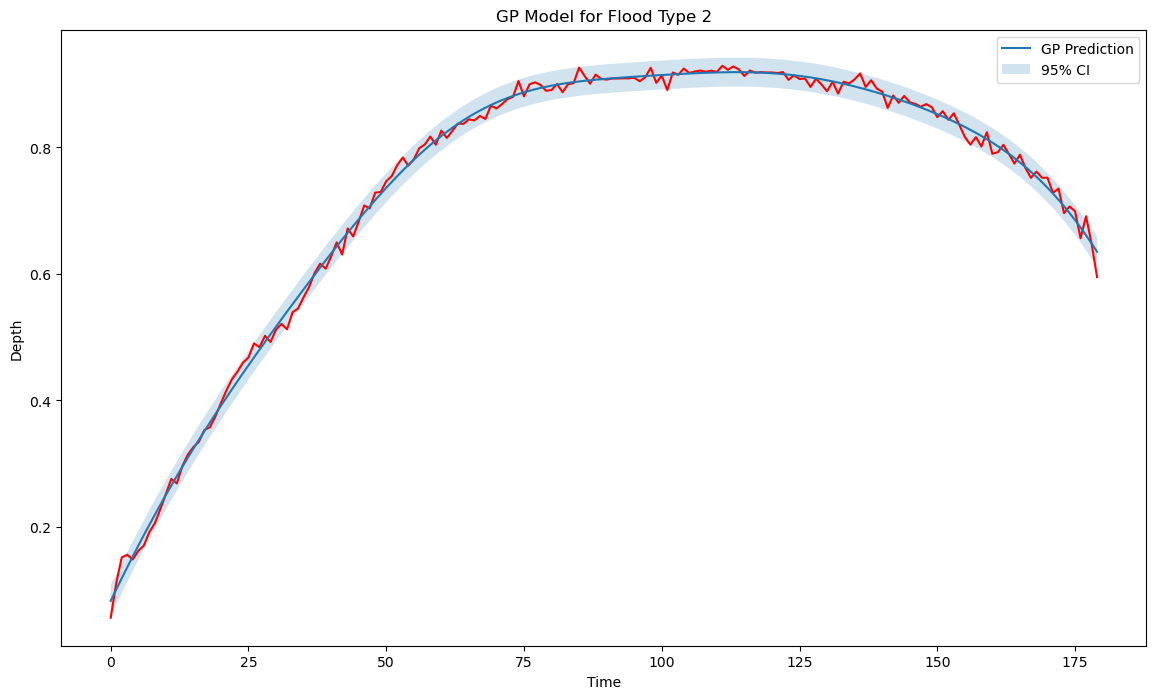

In [15]:
# Prepare features (X) and target (y)
X = np.arange(len(flood_type2)).reshape(-1, 1)
y = flood_type2

# Define the kernel and GP regressor
kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GP model
gp.fit(X, y)
 
y_pred, sigma = gp.predict(X, return_std=True)

# Visualization
plt.figure(figsize=(14, 8))
plt.plot(flood_type2, "r-")
plt.plot(X, y_pred, label=f'GP Prediction')
plt.fill_between(
    X.reshape(-1),
    y_pred - 1.96 * sigma,
    y_pred + 1.96 * sigma,
    alpha=0.2, label=f'95% CI'
    )

plt.xlabel('Time')
plt.ylabel('Depth')
plt.title('GP Model for Flood Type 2')
plt.legend()
plt.show()

In [16]:
with open('gp2.pkl','wb') as f:
    pickle.dump(gp,f)

### GP for flood type 3

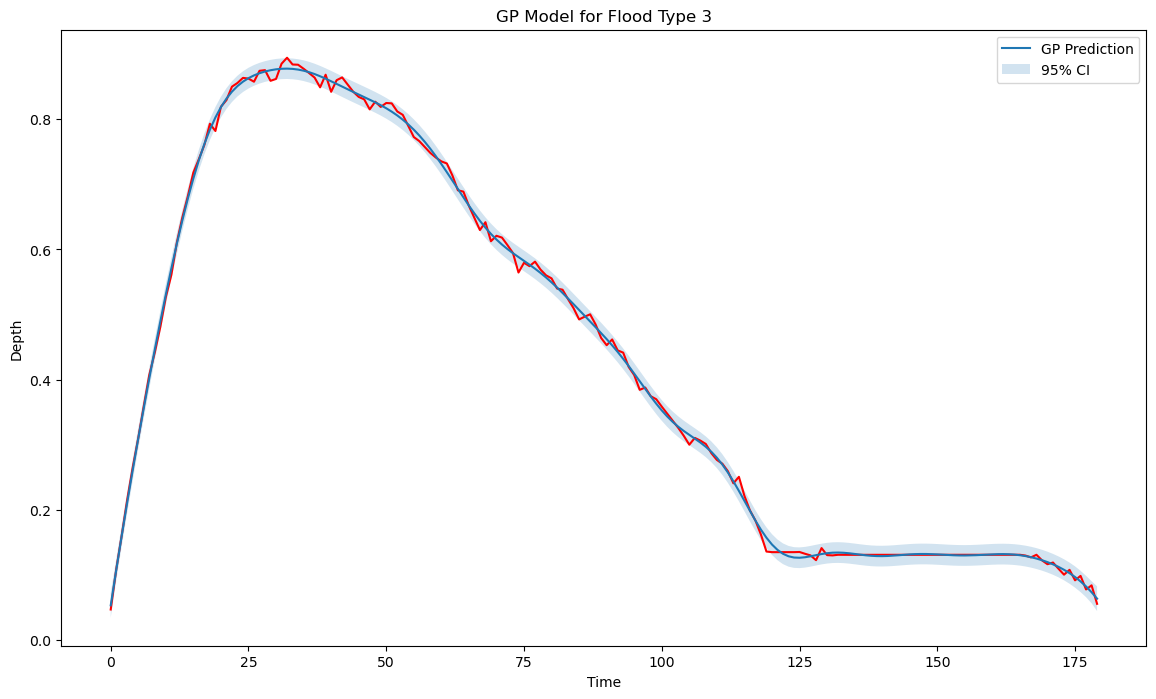

In [17]:
# Prepare features (X) and target (y)
X = np.arange(len(flood_type3)).reshape(-1, 1)
y = flood_type3

# Define the kernel and GP regressor
kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GP model
gp.fit(X, y)
 
y_pred, sigma = gp.predict(X, return_std=True)

# Visualization
plt.figure(figsize=(14, 8))
plt.plot(flood_type3, "r-")
plt.plot(X, y_pred, label=f'GP Prediction')
plt.fill_between(
    X.reshape(-1),
    y_pred - 1.96 * sigma,
    y_pred + 1.96 * sigma,
    alpha=0.2, label=f'95% CI'
    )

plt.xlabel('Time')
plt.ylabel('Depth')
plt.title('GP Model for Flood Type 3')
plt.legend()
plt.show()

In [18]:
with open('gp3.pkl','wb') as f:
    pickle.dump(gp,f)

### GP for type 4

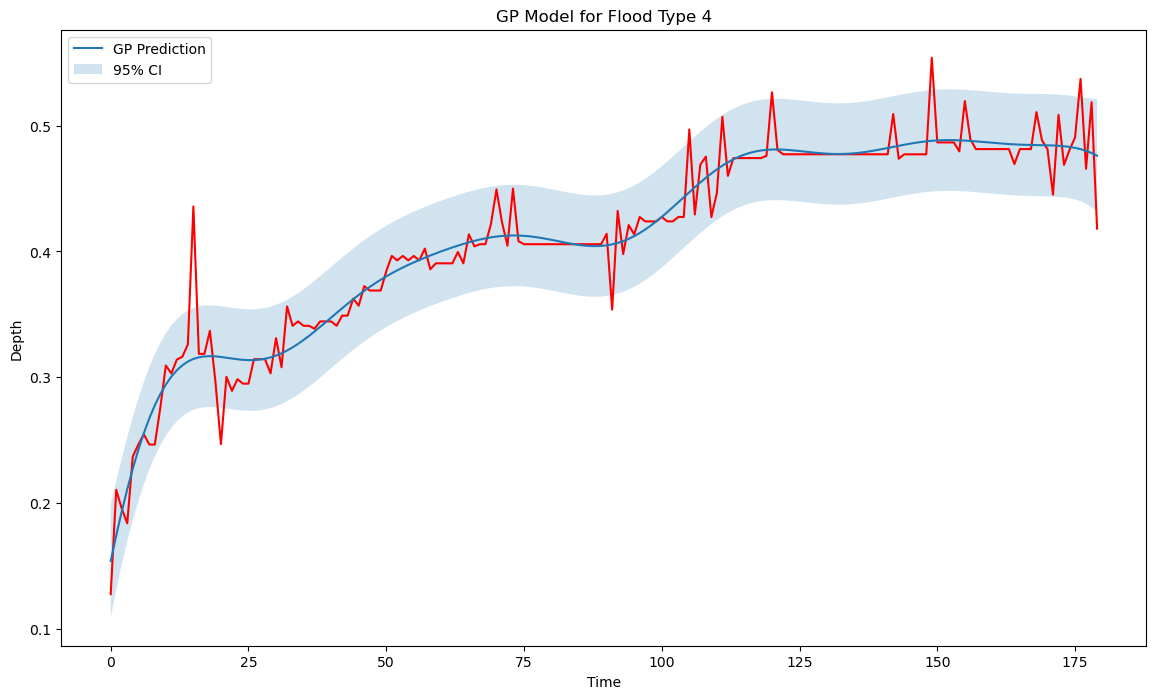

In [19]:
# Prepare features (X) and target (y)
X = np.arange(len(flood_type4)).reshape(-1, 1)
y = flood_type4

# Define the kernel and GP regressor
kernel = C(1.0, (1e-3, 1e3)) * RBF(10, (1e-2, 1e2)) + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10)

# Fit the GP model
gp.fit(X, y)
 
y_pred, sigma = gp.predict(X, return_std=True)

# Visualization
plt.figure(figsize=(14, 8))
plt.plot(flood_type4, "r-")
plt.plot(X, y_pred, label=f'GP Prediction')
plt.fill_between(
    X.reshape(-1),
    y_pred - 1.96 * sigma,
    y_pred + 1.96 * sigma,
    alpha=0.2, label=f'95% CI'
    )

plt.xlabel('Time')
plt.ylabel('Depth')
plt.title('GP Model for Flood Type 4')
plt.legend()
plt.show()

In [20]:
with open('gp4.pkl','wb') as f:
    pickle.dump(gp,f)